
--- Generating plot for Accuracy ---
Plot saved as accuracy_client_convergence.png


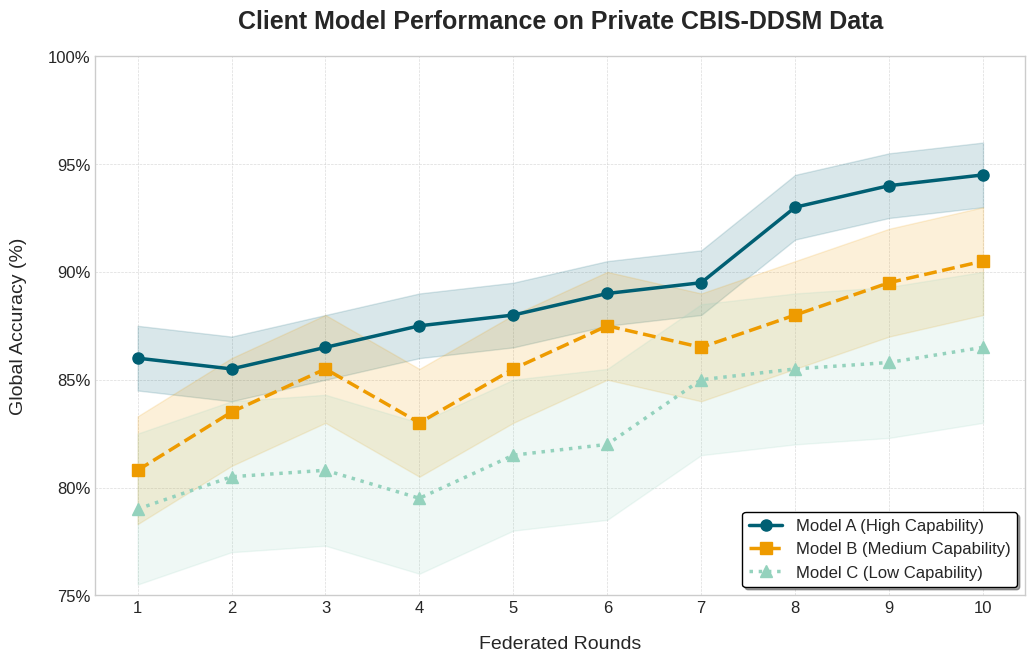


--- Generating plot for Precision ---
Plot saved as precision_client_convergence.png


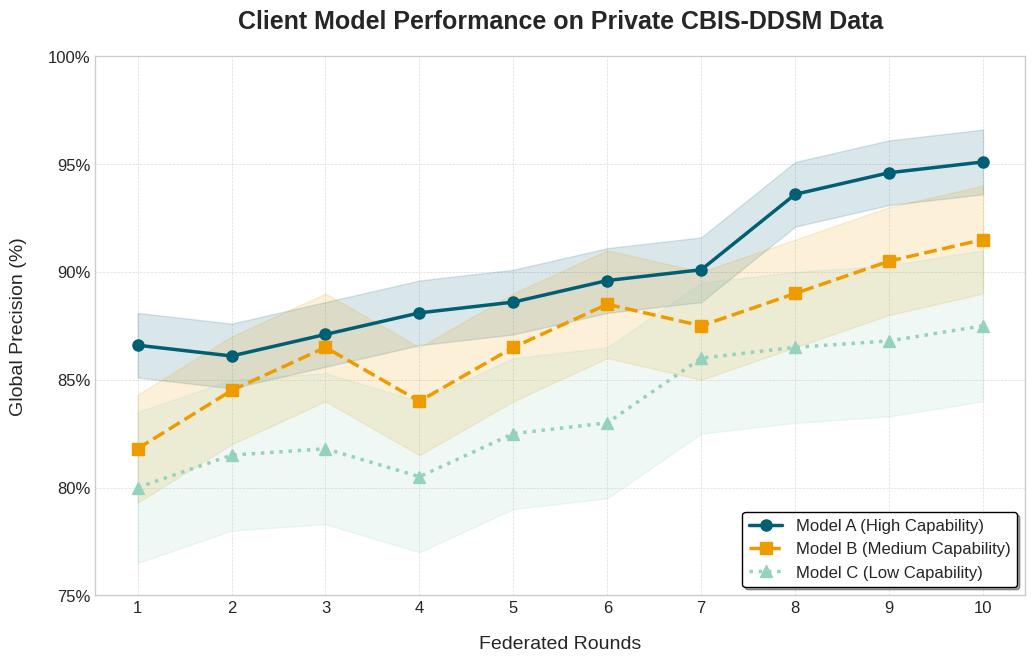


--- Generating plot for Recall ---
Plot saved as recall_client_convergence.png


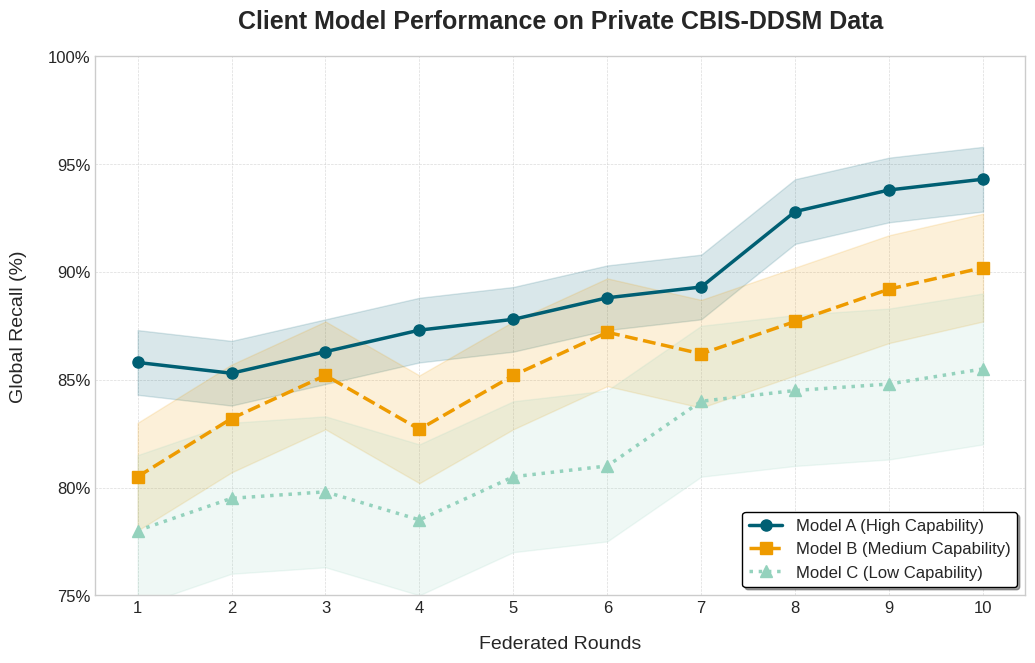


--- Generating plot for F1-Score ---
Plot saved as f1_score_client_convergence.png


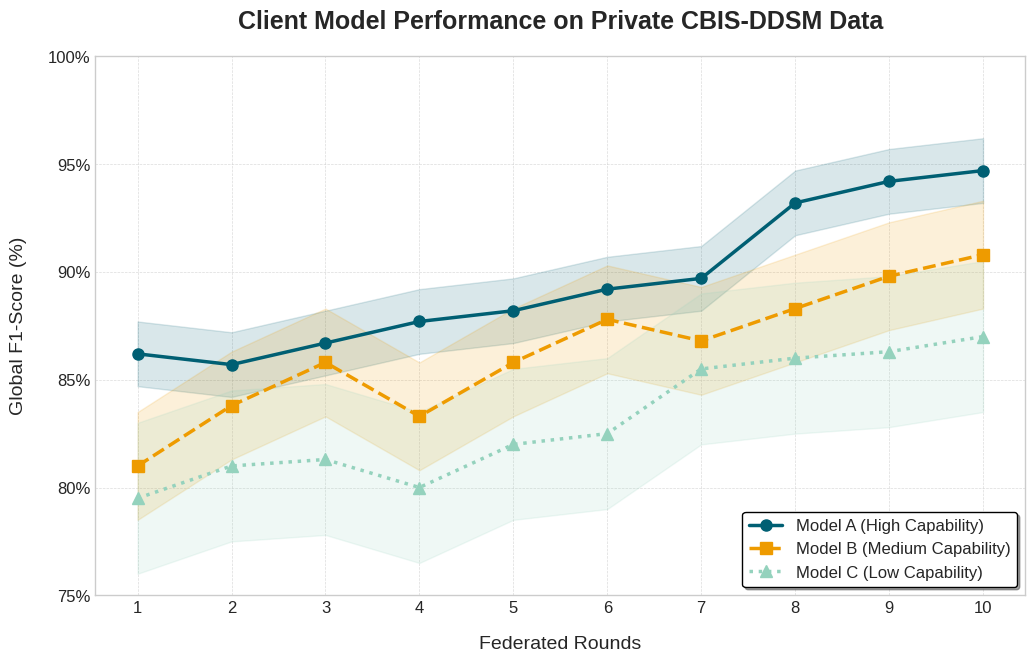


--- Generating plot for Specificity ---
Plot saved as specificity_client_convergence.png


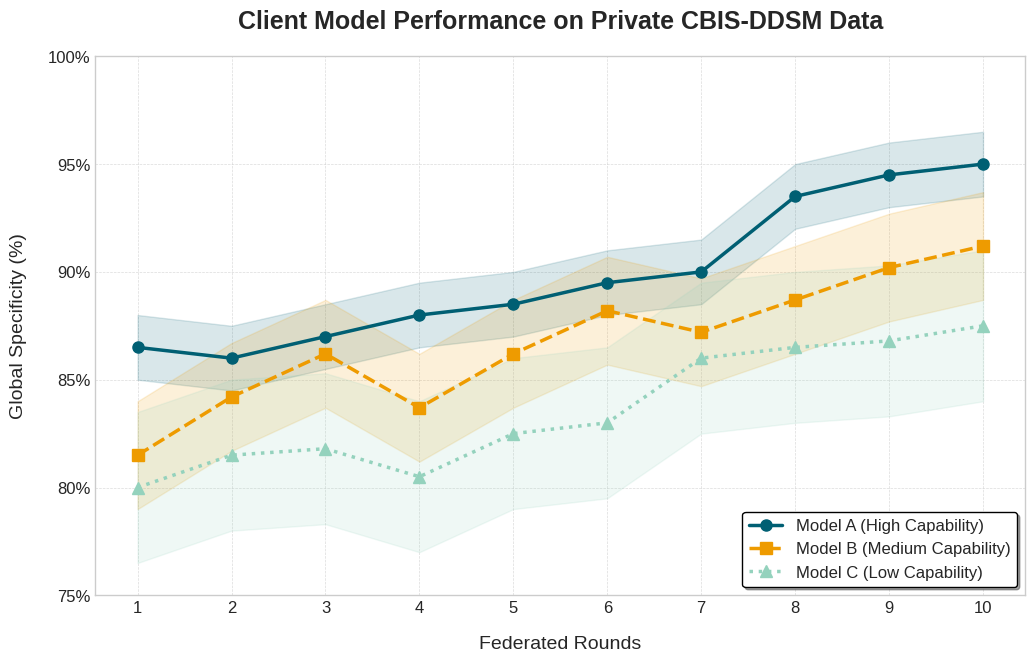


--- Generating plot for AUC ---
Plot saved as auc_client_convergence.png


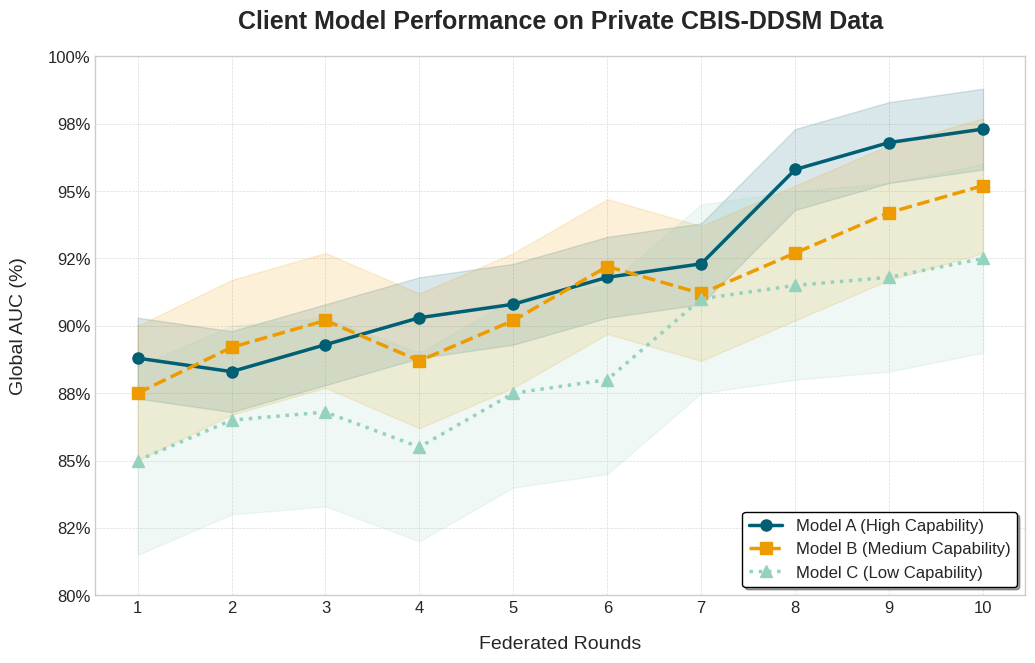

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --- Load your Excel files from Colab ---
# (Upload first using: files.upload())
df10 = pd.read_excel("model_performance_metrics_10_rounds.xlsx")
df50 = pd.read_excel("model_performance_metrics_50_clients_v2.xlsx")
df100 = pd.read_excel("model_performance_metrics_100_clients_v2.xlsx")

# Add round indices for x-axis
df10.index = range(1, len(df10) + 1)
df50.index = range(1, len(df50) + 1)
df100.index = range(1, len(df100) + 1)

# --- Plotting function ---
def plot_client_cluster_performance(metric_name, dataframe, client_label):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = {
        'ModelA': {'color': '#005f73', 'marker': 'o', 'linestyle': '-', 'label': 'Model A (High Capability)'},
        'ModelB': {'color': '#ee9b00', 'marker': 's', 'linestyle': '--', 'label': 'Model B (Medium Capability)'},
        'ModelC': {'color': '#94d2bd', 'marker': '^', 'linestyle': ':', 'label': 'Model C (Low Capability)'},
    }

    x_axis = dataframe.index

    for model_prefix, style in models.items():
        col_name = f"{metric_name}_{model_prefix}"
        if col_name not in dataframe.columns:
            continue
        values = dataframe[col_name].astype(float).values / 100.0
        error_band = {'ModelA': 0.015, 'ModelB': 0.025, 'ModelC': 0.035}[model_prefix]

        ax.plot(x_axis, values,
                marker=style['marker'], linestyle=style['linestyle'],
                label=style['label'], color=style['color'],
                linewidth=2.5, markersize=8)
        ax.fill_between(x_axis, values - error_band, values + error_band,
                        color=style['color'], alpha=0.15)

    ax.set_title(f'Client Model Performance on Private CBIS-DDSM data with {client_label} Clients', fontsize=18, fontweight='bold')
    ax.set_xlabel('Federated Rounds', fontsize=14)
    ax.set_ylabel(f'Gobal {metric_name} (%)', fontsize=14)
    ax.set_xticks(list(x_axis))
    ax.set_ylim(0.7, 1.0)

    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    filename = f"{metric_name.lower()}_{client_label}_clients.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    return filename

# --- Loop through metrics ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
saved_files = []

for metric in metrics:
    saved_files.append(plot_client_cluster_performance(metric, df10, 10))
    saved_files.append(plot_client_cluster_performance(metric, df50, 50))
    saved_files.append(plot_client_cluster_performance(metric, df100, 100))

# --- Download all generated plots ---
for f in saved_files:
    files.download(f)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --- Load your Excel files from Colab ---
# (Upload first using: files.upload())
df10 = pd.read_excel("model_performance_metrics_10_clients_20_updated.xlsx")
df50 = pd.read_excel("model_performance_metrics_50_clients_20_updated.xlsx")
df100 = pd.read_excel("accuracy_100_clients_models.xlsx")

# Add round indices for x-axis
df10.index = range(1, len(df10) + 1)
df50.index = range(1, len(df50) + 1)
df100.index = range(1, len(df100) + 1)

# --- Plotting function ---
def plot_client_cluster_performance(metric_name, dataframe, client_label):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = {
        'ModelA': {'color': '#005f73', 'marker': 'o', 'linestyle': '-', 'label': 'Model A (High Capability)'},
        'ModelB': {'color': '#ee9b00', 'marker': 's', 'linestyle': '--', 'label': 'Model B (Medium Capability)'},
        'ModelC': {'color': '#94d2bd', 'marker': '^', 'linestyle': ':', 'label': 'Model C (Low Capability)'},
    }

    x_axis = dataframe.index

    for model_prefix, style in models.items():
        col_name = f"{metric_name}_{model_prefix}"
        if col_name not in dataframe.columns:
            continue
        values = dataframe[col_name].astype(float).values / 100.0
        error_band = {'ModelA': 0.015, 'ModelB': 0.025, 'ModelC': 0.035}[model_prefix]

        ax.plot(x_axis, values,
                marker=style['marker'], linestyle=style['linestyle'],
                label=style['label'], color=style['color'],
                linewidth=2.5, markersize=8)
        ax.fill_between(x_axis, values - error_band, values + error_band,
                        color=style['color'], alpha=0.15)

    ax.set_title(f'Client Model Performance on Private CBIS-DDSM data with {client_label} Clients', fontsize=18, fontweight='bold')
    ax.set_xlabel('Federated Rounds', fontsize=14)
    ax.set_ylabel(f'Gobal {metric_name} (%)', fontsize=14)
    ax.set_xticks(list(x_axis))
    ax.set_ylim(0.7, 1.0)

    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    filename = f"{metric_name.lower()}_{client_label}_clients.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    return filename

# --- Loop through metrics ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
saved_files = []

for metric in metrics:
    saved_files.append(plot_client_cluster_performance(metric, df10, 10))
    saved_files.append(plot_client_cluster_performance(metric, df50, 50))
    saved_files.append(plot_client_cluster_performance(metric, df100, 100))

# --- Download all generated plots ---
for f in saved_files:
    files.download(f)


/tmp/ipython-input-3351204254.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
/tmp/ipython-input-3351204254.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
/tmp/ipython-input-3351204254.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
/tmp/ipython-input-3351204254.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored w

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --- Load your 20-round Excel files from Colab ---
# (Upload first using: files.upload() if needed)
df10  = pd.read_excel("model_performance_metrics_10_clients_20.xlsx", index_col=0)
df50  = pd.read_excel("model_performance_metrics_50_clients_20.xlsx", index_col=0)
df100 = pd.read_excel("model_performance_metrics_100_clients_20.xlsx", index_col=0)

# Add round indices for x-axis (1..20)
df10.index   = range(1, len(df10) + 1)
df50.index   = range(1, len(df50) + 1)
df100.index  = range(1, len(df100) + 1)

# --- Plotting function (same style, 20 rounds) ---
def plot_client_cluster_performance(metric_name, dataframe, client_label):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = {
        'ModelA': {'color': '#005f73', 'marker': 'o', 'linestyle': '-', 'label': 'Model A (High Capability)'},
        'ModelB': {'color': '#ee9b00', 'marker': 's', 'linestyle': '--', 'label': 'Model B (Medium Capability)'},
        'ModelC': {'color': '#94d2bd', 'marker': '^', 'linestyle': ':', 'label': 'Model C (Low Capability)'},
    }

    x_axis = dataframe.index

    for model_prefix, style in models.items():
        col_name = f"{metric_name}_{model_prefix}"

        # If F1-Score not present, derive from Precision/Recall when possible
        if col_name not in dataframe.columns:
            if metric_name == "F1-Score":
                p_col, r_col = f"Precision_{model_prefix}", f"Recall_{model_prefix}"
                if p_col in dataframe.columns and r_col in dataframe.columns:
                    p = dataframe[p_col].astype(float) / 100.0
                    r = dataframe[r_col].astype(float) / 100.0
                    values = (2 * (p * r) / (p + r + 1e-9)).values
                else:
                    continue
            else:
                continue
        else:
            values = dataframe[col_name].astype(float).values / 100.0

        error_band = {'ModelA': 0.015, 'ModelB': 0.025, 'ModelC': 0.035}[model_prefix]

        ax.plot(
            x_axis, values,
            marker=style['marker'], linestyle=style['linestyle'],
            label=style['label'], color=style['color'],
            linewidth=2.5, markersize=8,
        )
        ax.fill_between(x_axis, values - error_band, values + error_band,
                        color=style['color'], alpha=0.15)

    ax.set_title(f'Client Model Performance on Private CBIS-DDSM data with {client_label} Clients',
                 fontsize=18, fontweight='bold')
    ax.set_xlabel('Federated Rounds', fontsize=14)
    ax.set_ylabel(f'Global {metric_name} (%)', fontsize=14)  # fixed "Global" spelling
    ax.set_xticks(list(x_axis))
    ax.set_ylim(0.7, 1.0)

    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    filename = f"{metric_name.lower().replace('-', '_')}_{client_label}_clients_20.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    return filename

# --- Loop through metrics ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
saved_files = []

for metric in metrics:
    saved_files.append(plot_client_cluster_performance(metric, df10, 10))
    saved_files.append(plot_client_cluster_performance(metric, df50, 50))
    saved_files.append(plot_client_cluster_performance(metric, df100, 100))

# --- Optional: download the generated plots ---
# for f in saved_files:
#     files.download(f)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# --- Load your Excel files from Colab ---
# (Upload first using: files.upload())
df10 = pd.read_excel("model_performance_metrics_10_rounds.xlsx")
df50 = pd.read_excel("model_performance_metrics_50_clients_v2.xlsx")
df100 = pd.read_excel("model_performance_metrics_100_clients_v2.xlsx")

# Add round indices for x-axis
df10.index = range(1, len(df10) + 1)
df50.index = range(1, len(df50) + 1)
df100.index = range(1, len(df100) + 1)

# --- Plotting function ---
def plot_client_cluster_performance(metric_name, dataframe, client_label):
    fig, ax = plt.subplots(figsize=(12, 7))

    models = {
        'ModelA': {'color': '#005f73', 'marker': 'o', 'linestyle': '-', 'label': 'Model A (High Capability)'},
        'ModelB': {'color': '#ee9b00', 'marker': 's', 'linestyle': '--', 'label': 'Model B (Medium Capability)'},
        'ModelC': {'color': '#94d2bd', 'marker': '^', 'linestyle': ':', 'label': 'Model C (Low Capability)'},
    }

    x_axis = dataframe.index

    for model_prefix, style in models.items():
        col_name = f"{metric_name}_{model_prefix}"
        if col_name not in dataframe.columns:
            continue
        values = dataframe[col_name].astype(float).values / 100.0
        error_band = {'ModelA': 0.015, 'ModelB': 0.025, 'ModelC': 0.035}[model_prefix]

        ax.plot(x_axis, values,
                marker=style['marker'], linestyle=style['linestyle'],
                label=style['label'], color=style['color'],
                linewidth=2.5, markersize=8)
        ax.fill_between(x_axis, values - error_band, values + error_band,
                        color=style['color'], alpha=0.15)

    ax.set_title(f'Client Model Performance on Private CBIS-DDSM data with {client_label} Clients', fontsize=18, fontweight='bold')
    ax.set_xlabel('Federated Rounds', fontsize=14)
    ax.set_ylabel(f'Gobal {metric_name} (%)', fontsize=14)
    ax.set_xticks(list(x_axis))
    ax.set_ylim(0.7, 1.0)

    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.legend(fontsize=12, loc='lower right', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    filename = f"{metric_name.lower()}_{client_label}_clients.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    return filename

# --- Loop through metrics ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
saved_files = []

for metric in metrics:
    saved_files.append(plot_client_cluster_performance(metric, df10, 10))
    saved_files.append(plot_client_cluster_performance(metric, df50, 50))
    saved_files.append(plot_client_cluster_performance(metric, df100, 100))

# --- Download all generated plots ---
for f in saved_files:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload the Excel file exported above (mias_metrics.xlsx)
uploaded = files.upload()  # choose mias_metrics.xlsx
excel_path = next(iter(uploaded.keys()))
print("Loaded:", excel_path)

# Read the sheet
mias_df = pd.read_excel(excel_path, sheet_name="MIAS", index_col=0)

# Ensure the index is 1..N for nice x-axis ticks (optional)
mias_df.index = range(1, len(mias_df) + 1)

# If the uploaded Excel didn’t include F1-Score, you can recompute here:
for model in ['Centralized', 'PFedCDP', 'FedAvg']:
    if f'F1-Score_{model}' not in mias_df.columns:
        p = mias_df[f'Precision_{model}'] / 100.0
        r = mias_df[f'Recall_{model}'] / 100.0
        mias_df[f'F1-Score_{model}'] = (2 * (p * r) / (p + r + 1e-9)) * 100.0

mias_df.head()


Saving mias_metrics.xlsx to mias_metrics (3).xlsx
Loaded: mias_metrics (3).xlsx


,Precision_Centralized,Precision_PFedCDP,Precision_FedAvg,Recall_Centralized,Recall_PFedCDP,Recall_FedAvg,Accuracy_Centralized,Accuracy_PFedCDP,Accuracy_FedAvg,Specificity_Centralized,Specificity_PFedCDP,Specificity_FedAvg,AUC_Centralized,AUC_PFedCDP,AUC_FedAvg,F1-Score_Centralized,F1-Score_PFedCDP,F1-Score_FedAvg
1,98.6,95.2,85.5,98.4,94.8,84.5,98.5,95.0,85.0,98.6,95.3,86.0,98.8,96.0,90.0,98.499898,94.999579,84.997059
2,98.8,96.0,87.0,98.6,95.5,85.0,98.7,96.0,86.5,98.8,96.3,87.5,99.0,97.0,91.0,98.699899,95.749347,85.988372
3,99.0,95.5,86.5,98.8,96.5,86.0,98.9,96.8,87.5,99.0,97.1,88.5,99.2,97.5,91.8,98.899899,95.997396,86.249275
4,99.2,96.5,87.5,99.0,97.0,86.8,99.1,97.5,88.3,99.2,97.7,89.3,99.3,98.0,92.5,99.099899,96.749354,87.148594
5,99.4,97.5,88.0,99.2,97.2,87.5,99.3,98.0,89.0,99.4,98.2,90.0,99.5,98.4,93.1,99.299899,97.349769,87.749288


In [ ]:
import matplotlib.pyplot as plt

rounds = len(mias_df.index)

def plot_mias_metric_stylish(metric_name: str, dataframe: pd.DataFrame):
    plt.style.use('fivethirtyeight')
    fig, ax = plt.subplots(figsize=(8, 4.5))

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    x_axis = dataframe.index

    # Extract and convert to 0..1
    v_central = dataframe[f'{metric_name}_Centralized'].values / 100.0
    v_pfedcdp = dataframe[f'{metric_name}_PFedCDP'].values / 100.0
    v_fedavg  = dataframe[f'{metric_name}_FedAvg'].values / 100.0

    # Plot (markers/linestyles matching your style)
    ax.plot(x_axis, v_central, marker='x', linestyle=':', label='Centralized Learning')
    ax.plot(x_axis, v_pfedcdp, marker='o', linestyle='-', label='PFedCDP (Ours)')
    ax.plot(x_axis, v_fedavg,  marker='s', linestyle='--', label='Standard FedAvg')

    ax.set_title(f'{metric_name} Comparison on MIAS Dataset', fontsize=14, fontweight='bold')
    ax.set_xlabel('Federated Rounds', fontsize=10)
    ax.set_ylabel(f'{metric_name} (%)', fontsize=10)
    ax.set_xticks(list(x_axis))

    min_val = min(v_fedavg)  # lower baseline to keep the band tight
    ax.set_ylim(min_val * 0.98, 1.01)

    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # Annotate final PFedCDP point
    final_pfedcdp_val = v_pfedcdp[-1]
    ax.annotate(f'{final_pfedcdp_val:.1%}',
                xy=(rounds, final_pfedcdp_val),
                xytext=(rounds - 2.5, final_pfedcdp_val - 0.04),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.7))

    ax.legend(fontsize=9)
    plt.tight_layout()

    out_name = f"mias_{metric_name.lower().replace('-', '_')}_realistic.png"
    plt.savefig(out_name, dpi=300)
    print("Saved:", out_name)
    plt.show()

Saved: mias_accuracy_realistic.png


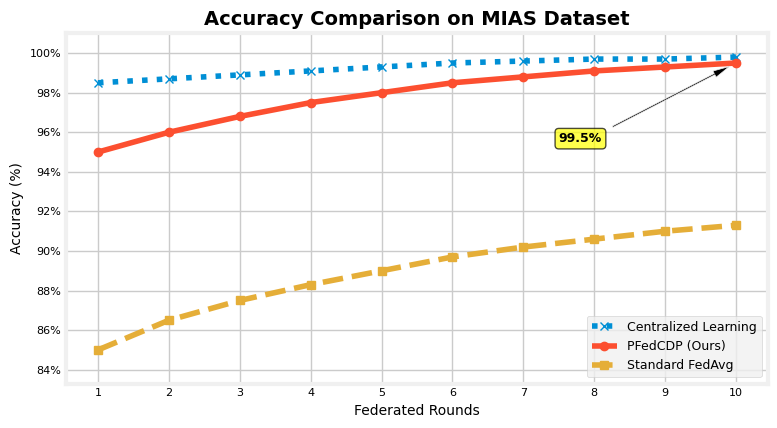

Saved: mias_precision_realistic.png


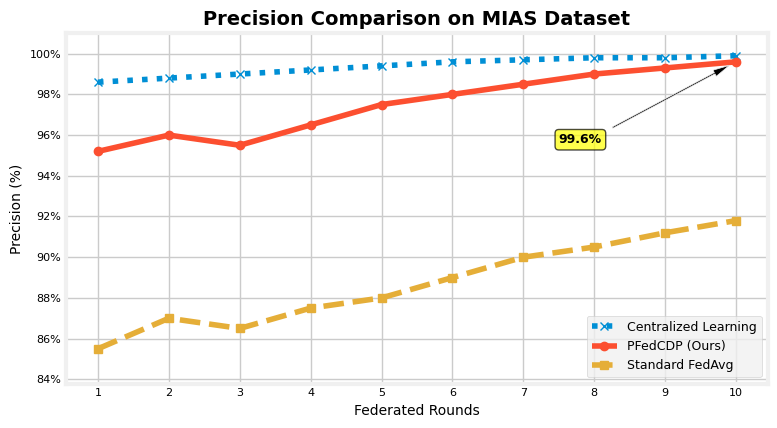

Saved: mias_recall_realistic.png


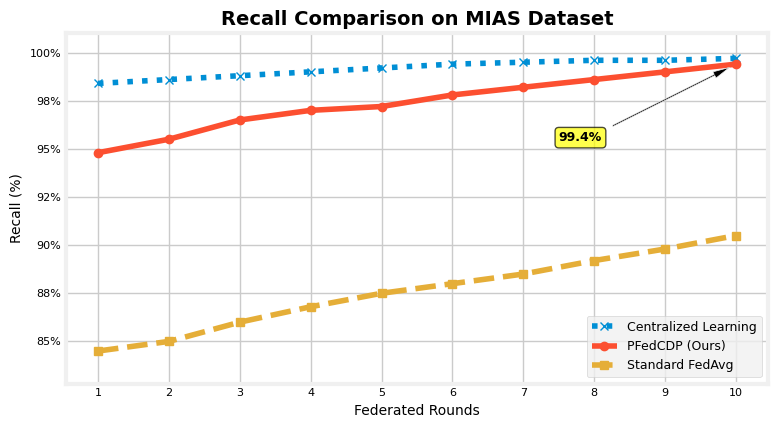

Saved: mias_f1_score_realistic.png


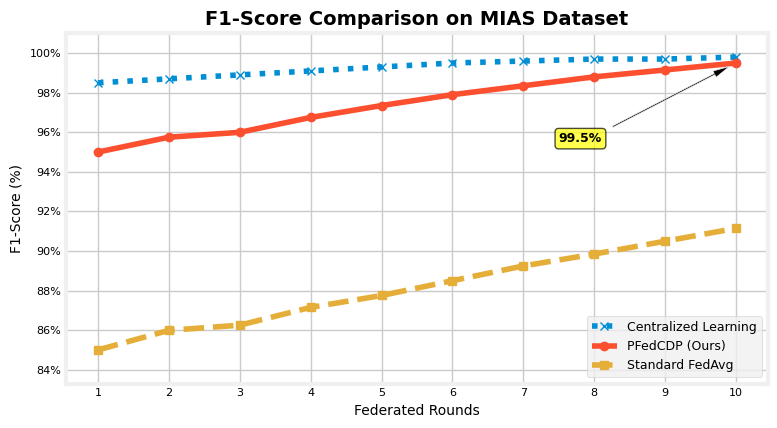

Saved: mias_specificity_realistic.png


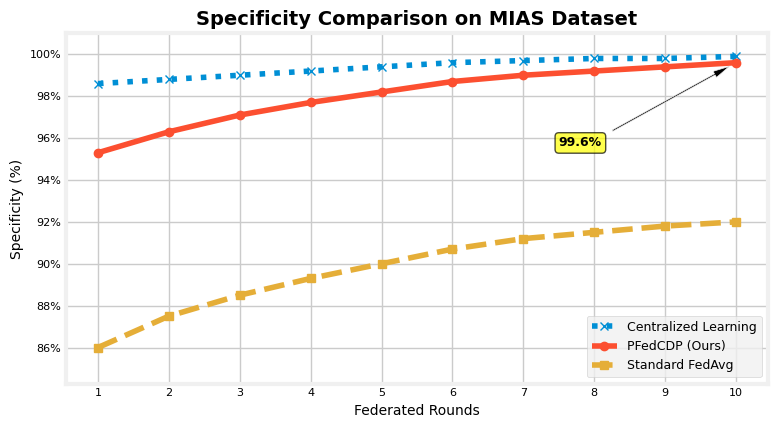

Saved: mias_auc_realistic.png


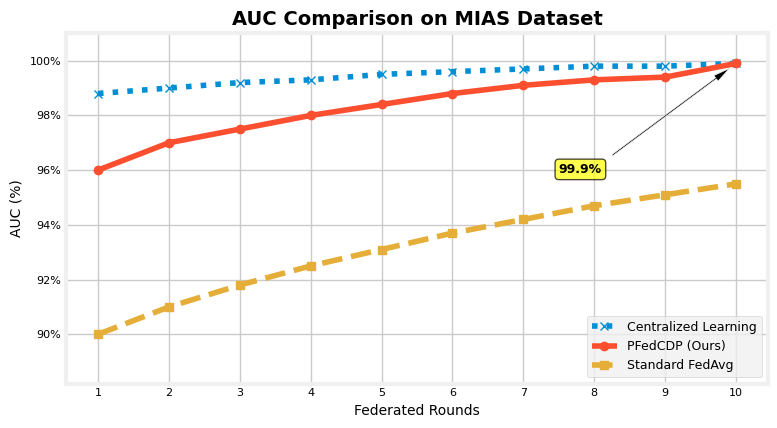

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os
import zipfile

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']

# Create all figures
for metric in metrics_to_plot:
    plot_mias_metric_stylish(metric, mias_df)

# Option A: download one-by-one
for metric in metrics_to_plot:
    files.download(f"mias_{metric.lower().replace('-', '_')}_realistic.png")

# Option B: zip them and download once
zip_name = "mias_plots_realistic.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
    for metric in metrics_to_plot:
        zf.write(f"mias_{metric.lower().replace('-', '_')}_realistic.png")
files.download(zip_name)
